In [3]:
# ===========================
# 1. SETUP
# ===========================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv("household_cleaned (1).csv")

df.head()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40835 entries, 0 to 40834
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Village_Survey_ID            40835 non-null  int64  
 1   Is_Family_Head               40835 non-null  int64  
 2   Head_Gender                  40835 non-null  int64  
 3   Male_Members                 40835 non-null  int64  
 4   Female_Members               40835 non-null  int64  
 5   Earning_Adult_Members        40835 non-null  int64  
 6   Earning_Members'_Children    40835 non-null  int64  
 7   House_Type                   40835 non-null  int64  
 8   House_Owned                  40835 non-null  int64  
 9   Electricity_Available        40835 non-null  int64  
 10  TV_Available                 40835 non-null  int64  
 11  Radio_Available              40835 non-null  int64  
 12  MobilePhone_Available        40835 non-null  int64  
 13  Smartphone_Avail

,Village_Survey_ID,Is_Family_Head,Head_Gender,Male_Members,Female_Members,Earning_Adult_Members,Earning_Members'_Children,House_Type,House_Owned,Electricity_Available,...,Travel_Time_Minutes,NADRA_Registration,FormB_Registration,Changed_School,Reason_Change_School,Education_Expense,Schooling_Affected,Mother_Language,Religion,FunctionalToilet
count,40835.000000,40835.000000,40835.000000,40835.000000,40835.000000,40835.000000,40835.000000,40835.00000,40835.000000,40835.000000,...,40834.000000,40834.000000,40834.000000,40834.000000,40834.000000,40834.000000,40834.000000,40834,40834,40834.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,139,56,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pushto,Islam,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17449,35688,NaN
mean,268786.886103,0.525162,1.140198,2.770246,2.440162,22.716150,0.038594,2.16241,0.774874,0.832644,...,1.242029,1.950727,1.801073,0.024440,7.000784,4132.242053,3.648993,NaN,NaN,0.985551
std,16499.690626,0.499373,0.350776,1.365910,1.385917,2542.410947,0.291811,0.76851,0.417670,0.373298,...,0.514360,1.631980,1.626133,0.154414,0.347610,4789.834948,0.825654,NaN,NaN,0.119333
min,30042.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,300.000000,1.000000,NaN,NaN,0.000000
25%,264889.000000,0.000000,1.000000,2.000000,2.000000,1.000000,0.000000,2.00000,1.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,7.000000,2000.000000,4.000000,NaN,NaN,1.000000
50%,265521.000000,1.000000,1.000000,3.000000,2.000000,1.000000,0.000000,2.00000,1.000000,1.000000,...,1.000000,2.000000,2.000000,0.000000,7.000000,3000.000000,4.000000,NaN,NaN,1.000000
75%,266208.000000,1.000000,1.000000,3.000000,3.000000,1.000000,0.000000,3.00000,1.000000,1.000000,...,1.000000,3.000000,3.000000,0.000000,7.000000,4500.000000,4.000000,NaN,NaN,1.000000


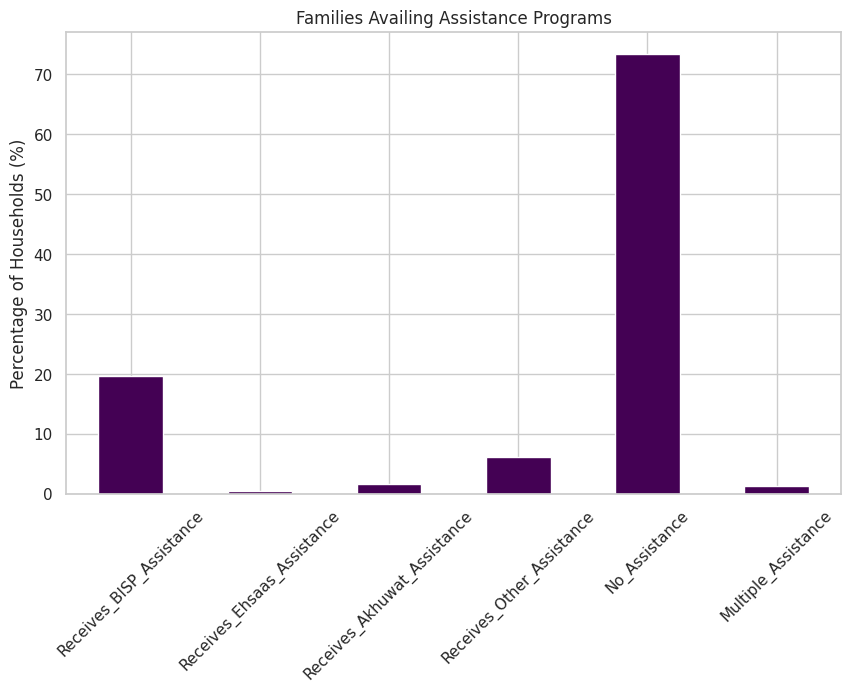

In [16]:
import matplotlib.pyplot as plt

# Assistance columns
assist_cols = [
    "Receives_BISP_Assistance", "Receives_Ehsaas_Assistance",
    "Receives_Akhuwat_Assistance", "Receives_Other_Assistance"
]

# Clean column names
df.columns = df.columns.str.strip()

# Convert assistance columns to 0/1 (handles 'Yes', '1', 'True')
for col in assist_cols:
    df[col] = df[col].apply(lambda x: 1 if str(x).strip().lower() in ["1","yes","true"] else 0)

# Calculate mean percentage for each individual assistance program
assist_means = df[assist_cols].mean() * 100

# Count number of assistance programs each family receives
df['assist_count'] = df[assist_cols].sum(axis=1)

# Add categories
assist_means["No_Assistance"] = (df['assist_count'] == 0).mean() * 100
assist_means["Multiple_Assistance"] = (df['assist_count'] > 1).mean() * 100

# Plot
assist_means.plot(kind="bar", figsize=(10,6), colormap="viridis")
plt.ylabel("Percentage of Households (%)")
plt.title("Families Availing Assistance Programs")
plt.xticks(rotation=45)
plt.show()


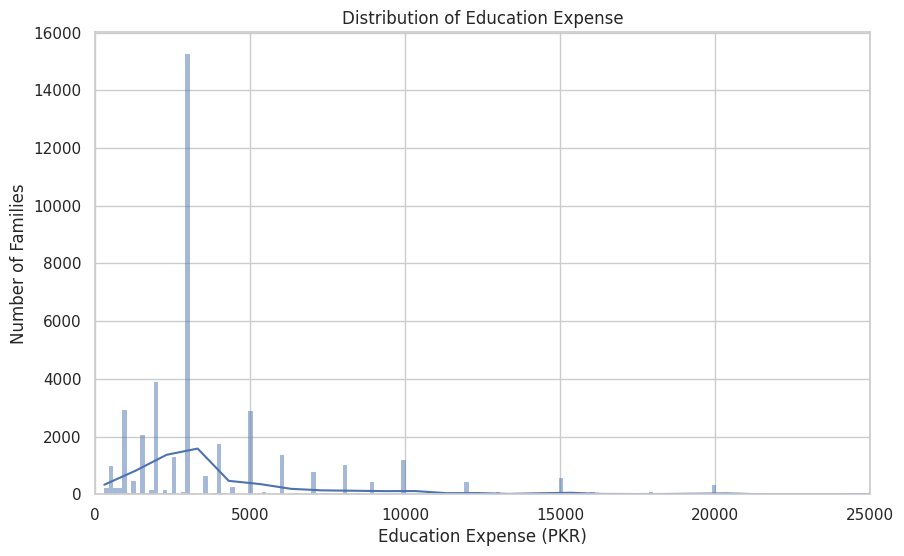

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(df['Education_Expense'], kde=True)
plt.title("Distribution of Education Expense")
plt.xlabel("Education Expense (PKR)")
plt.ylabel("Number of Families")  # meaningful y-axis label
plt.xlim(0, 25000)  # limit x-axis to the main data range
plt.show()



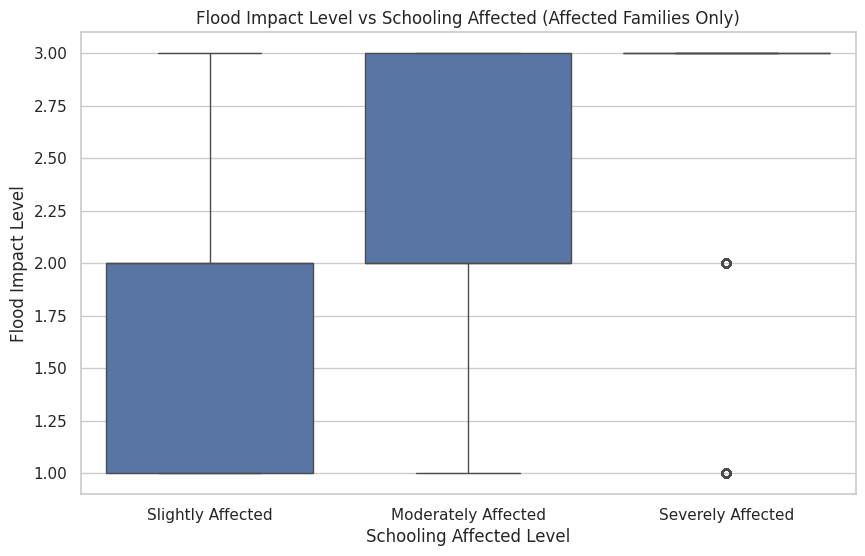

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Map numeric codes to meaningful labels
schooling_map = {
    2: "Slightly Affected",
    3: "Moderately Affected",
    4: "Severely Affected"
}

# Filter out 'Not Affected' (1)
df_affected = df[df['Schooling_Affected'] != 1].copy()

# Create a new column with labels
df_affected['Schooling_Affected_Label'] = df_affected['Schooling_Affected'].map(schooling_map)

# Define the order for plotting
order = ["Slightly Affected", "Moderately Affected", "Severely Affected"]

# Plot
plt.figure(figsize=(10,6))
sns.boxplot(data=df_affected, x="Schooling_Affected_Label", y="Flood_Impact_Level", order=order)
plt.title("Flood Impact Level vs Schooling Affected (Affected Families Only)")
plt.xlabel("Schooling Affected Level")
plt.ylabel("Flood Impact Level")
plt.show()


/tmp/ipython-input-4066345219.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




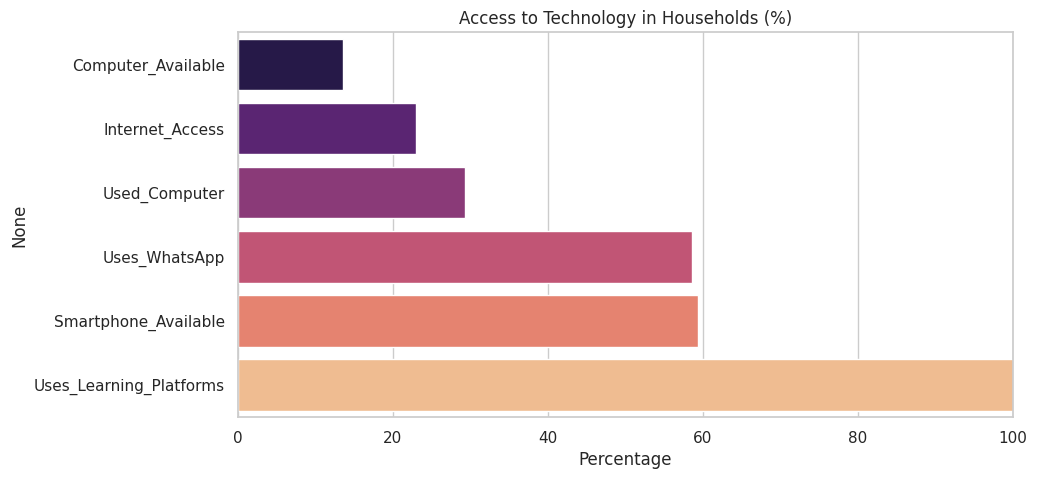

In [34]:
tech_cols = [
    "Internet_Access","Computer_Available",
    "Used_Computer","Smartphone_Available",
    "Uses_WhatsApp","Uses_Learning_Platforms"
]

# Convert tech_cols to integer type before calculating mean
tech_df = df[tech_cols].astype(int).mean().sort_values() * 100 # Multiply by 100 for percentage

plt.figure(figsize=(10,5))
sns.barplot(x=tech_df.values, y=tech_df.index, palette="magma")
plt.title("Access to Technology in Households (%)")
plt.xlabel("Percentage")
plt.xlim(0, 100) # Set x-axis limit to 0-100 for percentage
plt.show()

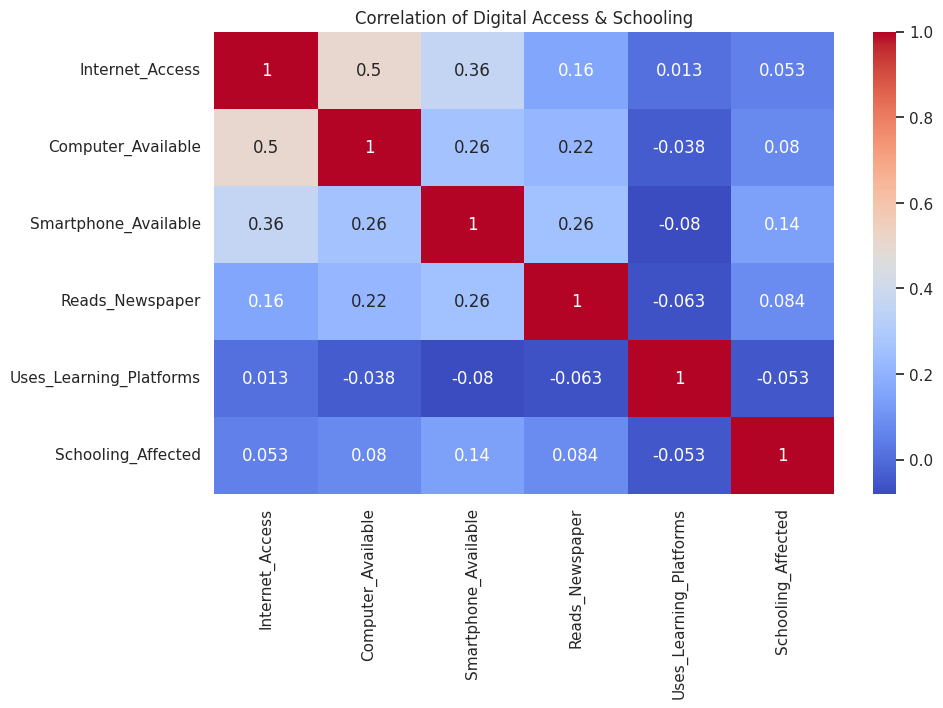

In [35]:
digital_cols = [
    "Internet_Access","Computer_Available",
    "Smartphone_Available","Reads_Newspaper",
    "Uses_Learning_Platforms","Schooling_Affected"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[digital_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation of Digital Access & Schooling")
plt.show()


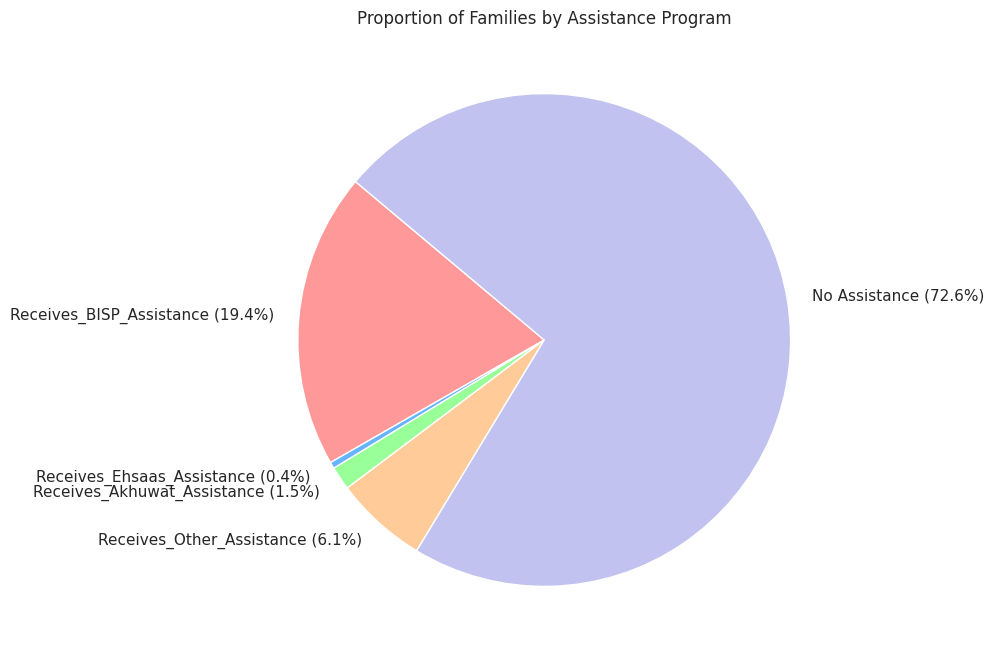

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

# Assistance columns
assist_cols = [
    "Receives_BISP_Assistance",
    "Receives_Ehsaas_Assistance",
    "Receives_Akhuwat_Assistance",
    "Receives_Other_Assistance"
]

# Convert assistance columns to 0/1
for col in assist_cols:
    df[col] = df[col].apply(lambda x: 1 if str(x).strip().lower() in ["1","yes","true"] else 0)

# Calculate counts per assistance program
assist_counts = df[assist_cols].sum()

# Calculate number of families receiving no assistance
no_assist_count = (df[assist_cols].sum(axis=1) == 0).sum()

# Combine into one series for the pie chart using pd.concat
all_counts = pd.concat([assist_counts, pd.Series({"No Assistance": no_assist_count})])

# Calculate percentages
total = all_counts.sum()
percentages = all_counts / total * 100

# Create labels with name and percentage
labels = [f"{name} ({perc:.1f}%)" for name, perc in zip(all_counts.index, percentages)]

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(all_counts, labels=labels, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'],
        startangle=140, wedgeprops={'edgecolor': 'w'})
plt.title("Proportion of Families by Assistance Program")
plt.show()